# Model Analysis: S&P 500 Options (Hold-to-Expiry Straddles)

This notebook evaluates all predictive models trained on the S&P 500 options
case study. The central finding: **modest cross-sectional ML signal, combined
with a hold-to-expiry payoff and a liquid-universe filter, delivers a viable
but modest single-stock straddle strategy.**

The prediction target is the **hold-to-expiry straddle return**
(`ret_to_expiry`): enter an ATM straddle at the bid, hold until expiration,
and settle at intrinsic value. A positive value means realized movement was
smaller than implied - the option seller pockets the **volatility risk
premium (VRP)**. The hold-to-expiry (HTM) structure pays the entry
half-spread only; there is no closing trade and no exit spread.

Models achieve modest IC on `ret_to_expiry`. The highest-IC config per
family on the validation set is `gbm/leaves_63_mae` at IC=+0.0182
(HAC t=2.42, CI excludes zero), `deep_learning/patchtst` at +0.0135
(t=2.07, just excludes zero), `linear/ridge_a0.001` at +0.0071 (CI
straddles zero), and `tabular_dl/tabm_l` at +0.0017 (straddles zero).
The canonical strategy - `linear/ridge_a1000000.0`, equal-weight top-5,
restricted to the bottom-quintile-half-spread liquid universe per
O'Donovan and Yu (2024) - reaches Sharpe +0.160 on validation and
+0.974 on the 2021 holdout. Note that this canonical lineage selects
the highest-Sharpe linear ridge (heavy regularization, near-flat
predictions) rather than the highest-IC `ridge_a0.001` - a divergence
discussed in §8.

The opening lesson: **a modest signal plus a tight liquid-universe filter
plus a hold-to-expiry payoff yields a defensible cross-sectional VRP
strategy**. The full single-stock option universe remains punishing - round-
trip spreads consume the edge - which is exactly what the liquid-universe
filter side-steps.

With only 2 expanding-window folds covering 2017-2020 (validation) and a
single 2021 holdout, the statistical evidence is thinner than in case
studies with 8+ folds, and the 2-fold caveat applies throughout.

**Learning Objectives**:
- Understand the hold-to-expiry payoff for short straddles (intrinsic-value
  settle, entry-only half-spread cost) and why it differs from a marked-to-
  mid view.
- Evaluate whether modest IC (+0.02 range) reflects genuine cross-sectional
  VRP structure or noise, given only 2 expanding-window folds.
- Compare model families (linear, GBM, PatchTST, TabM) on a single-label
  VRP prediction task.
- See how IC-highest versus Sharpe-highest configs can diverge:
  regularization shrinks predictions and reduces dispersion, raising Sharpe
  while lowering IC.
- Make evidence-based decisions about which family to backtest given the
  2-fold confidence interval.

**Prerequisites**: Model training notebooks Ch11-15 must have run for this
case study. Results come from the registry (`run_log/registry.db`).

**Book Reference**: This notebook bridges Part III (Models, Ch11-15) and
Part IV (Strategy Implementation, Ch16-20). The chapter insights notebooks
compare each model family *across* case studies; here we compare all
families *within* a single dataset.

In [1]:
"""Model Analysis: S&P 500 Options - comparative evaluation across all model families."""

import warnings

import numpy as np
import polars as pl
import yaml

from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "sp500_options"
PRIMARY_LABEL = "ret_to_expiry"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 63

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")

# sp500_options has a different cost structure: option spread + hedge costs
# The notional-equivalent cost is ~87 bps per leg (12% of premium)
cost_range = setup["costs"].get("per_leg_cost_bps_range", [87, 87])
cost_class = setup["costs"].get("class", "dominant")

# Universe size: compute from features since setup.yaml doesn't store n_assets
features_path = CASE_DIR / "features" / "financial.parquet"
if features_path.exists():
    _feat_df = pl.scan_parquet(features_path).select(ENTITY_COL).collect()
    n_assets = _feat_df[ENTITY_COL].n_unique()
    del _feat_df
else:
    n_assets = 0

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} S&P 500 option straddles")
print(f"  Label: {PRIMARY_LABEL} (hold-to-expiry straddle return = VRP, settle at intrinsic)")
print(f"  CV: {n_splits} expanding-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(
    f"  Trading costs: {cost_range[0]}-{cost_range[1]} bps notional equivalent (cost class: {cost_class})"
)

Case Study: sp500_options
  Universe: 612 S&P 500 option straddles
  Label: ret_to_expiry (hold-to-expiry straddle return = VRP, settle at intrinsic)
  CV: 2 expanding-window folds, train=2Y, val=1Y
  Holdout: 2021-01-01 onwards
  Trading costs: 87-87 bps notional equivalent (cost class: dominant)


## 1. What Is the Prediction Problem?

**Primary target tuple**: `ret_to_expiry` | regression | IC | monthly straddle holding (entry T, exit at expiration)

We predict the **hold-to-expiry straddle return** for each S&P 500
constituent's ATM straddle. The straddle is entered at the bid on
entry date $T$ and settled at intrinsic value at expiration $T_E$ -
typically 25-35 calendar days later. There is no closing trade and
no exit spread; only the entry half-spread is paid.

At settlement the P&L on a unit short straddle is:

$$\text{Straddle P\&L} = (\text{Premium}_{\text{bid}}) - \max(0,\, |S_{T_E} - K|)$$

When realized movement $|S_{T_E} - K|$ is smaller than the implied
premium collected, the option seller wins - this is the cross-sectional
**volatility risk premium (VRP)**. The model's job is to rank which
options are *most* overpriced at entry, where overpriced means implied
volatility most exceeds what realized movement will deliver over the
holding period.

The feature set (52 features) emphasizes implied volatility
surface characteristics: ATM IV level, OTM IV, put-call skew,
historical-implied volatility spread, IV term structure, VIX
level, and realized-implied gap. These are option-specific
features that would be meaningless for directional prediction.

The universe spans up to 612 S&P 500 constituents with liquid
options - a large cross-section, though not all names have
options at every date. The canonical strategy restricts to the
bottom-quintile half-spread subset (the *liquid universe*) per
`setup.yaml::strategy.signal.universe_filter='liquid'`, following
O'Donovan and Yu (2024): single-name option spreads are wide enough
that the modest VRP edge only survives when the universe itself is
filtered to the cheapest-to-trade names. Costs apply only at entry
under HTM (see `setup.yaml::costs.option_spread.entry_cost_fractions`);
the exit settles at intrinsic and pays nothing.

In [4]:
# Phase 1: Load pre-computed metrics for ALL labels (coverage + multi-label analysis)
all_labels_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check
EXPECTED_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"}
missing = EXPECTED_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\nWARNING: COVERAGE: {n_present}/6 model families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nOK: Full coverage: all 6 model families present.")

Pre-computed metrics: 50 entries across 4 families
  deep_learning           2 configs    2 checkpoints  best IC=+0.0135
  gbm                    15 configs    0 checkpoints  best IC=+0.0182
  linear                 30 configs    0 checkpoints  best IC=+0.0071
  tabular_dl              3 configs    2 checkpoints  best IC=+0.0022

  Recommendations below may change when missing families are added.


In [5]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (4, 5)
┌───────────────┬───────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name   ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---           ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str           ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪═══════════════╪══════════════════╪══════════╪══════════╡
│ gbm           ┆ leaves_63_mae ┆ null             ┆ 0.018164 ┆ 0.020378 │
│ deep_learning ┆ patchtst      ┆ 5                ┆ 0.013471 ┆ 0.000101 │
│ linear        ┆ ridge_a0.001  ┆ null             ┆ 0.007109 ┆ 0.008981 │
│ tabular_dl    ┆ tabm_l        ┆ 50               ┆ 0.002151 ┆ 0.006296 │
└───────────────┴───────────────┴──────────────────┴──────────┴──────────┘


In [6]:
# Phase 2: Load raw predictions ONLY for the ~4 best models (not all)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded gbm/leaves_63_mae: 142,941 predictions
  Loaded deep_learning/patchtst: 139,102 predictions
  Loaded linear/ridge_a0.001: 142,941 predictions
  Loaded tabular_dl/tabm_l: 571,764 predictions

Total representative predictions: 996,748


In [7]:
# Fold date ranges for timeline
if best_preds.height > 0:
    _date_dtype = best_preds[DATE_COL].dtype
    if _date_dtype == pl.String:
        _date_expr = pl.col(DATE_COL).str.to_datetime(strict=False).cast(pl.Date)
    else:
        _date_expr = pl.col(DATE_COL).cast(pl.Date)
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .with_columns(_date_expr)
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().alias("val_start"),
            pl.col(DATE_COL).max().alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

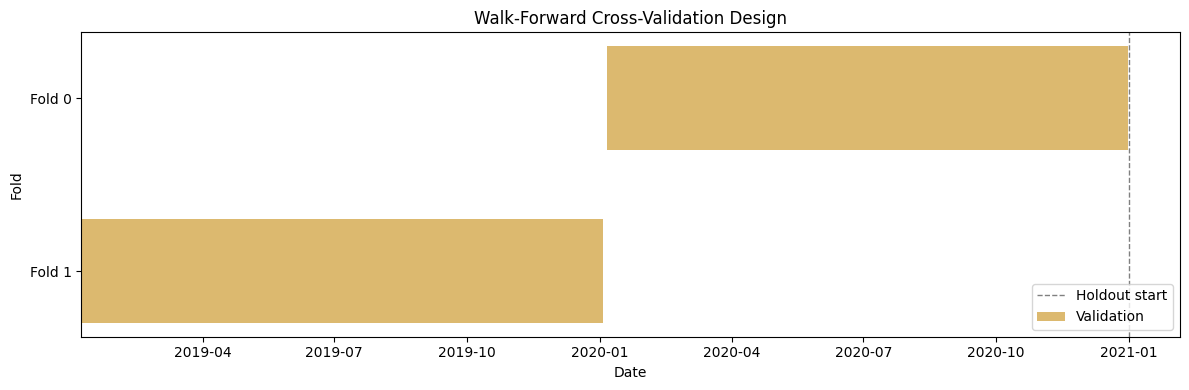

In [8]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

With only 2 walk-forward folds, statistical confidence is inherently
limited. Each fold covers approximately one year of validation data.
A model that works in both folds is encouraging but two observations
cannot establish robustness. This is the most important caveat
throughout this analysis - any finding here needs confirmation
through additional out-of-sample testing (including the holdout
period from 2021 onwards).

The 2-fold limitation is a direct consequence of the shorter options
data history (2017-2021) compared to the equity case studies that
span 15+ years.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11-13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. Forcing all of these into a single ranking would be
misleading.

In [9]:
# Coverage map: family x label x evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families x Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families x Labels
shape: (4, 6)
┌─────────┬───────────────┬───────────────┬────────────┬───────────┬──────────┐
│ chapter ┆ family        ┆ label         ┆ evidence   ┆ n_configs ┆ best_ic  │
│ ---     ┆ ---           ┆ ---           ┆ ---        ┆ ---       ┆ ---      │
│ str     ┆ str           ┆ str           ┆ str        ┆ u32       ┆ f64      │
╞═════════╪═══════════════╪═══════════════╪════════════╪═══════════╪══════════╡
│ Ch13    ┆ deep_learning ┆ ret_to_expiry ┆ predictive ┆ 2         ┆ 0.013471 │
│ Ch12    ┆ gbm           ┆ ret_to_expiry ┆ predictive ┆ 15        ┆ 0.018164 │
│ Ch11    ┆ linear        ┆ ret_to_expiry ┆ predictive ┆ 30        ┆ 0.007109 │
│ Ch12    ┆ tabular_dl    ┆ ret_to_expiry ┆ predictive ┆ 3         ┆ 0.002151 │
└─────────┴───────────────┴───────────────┴────────────┴───────────┴──────────┘


In [10]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (ret_to_expiry):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: none
  Causal families: none

All labels trained: ['ret_to_expiry']


Four predictive families (linear, GBM, PatchTST, TabM) are trained on
the single primary label `ret_to_expiry`, spanning three of the five
modeling chapters. Latent factor models (Ch14) and causal DML (Ch15)
are not trained for this case study (the latent-factor rationale is
discussed in §7; causal DML is trained but evaluated as a separate
evidence block, not as a predictive ranker).

The case study is scoped to a single label. Four legacy diagnostic
horizons (`fwd_ret_5d`, `fwd_ret_10d`, `fwd_ret_dh_5d`,
`fwd_ret_dh_10d`) were dropped from the registry on 2026-05-17
because the vectorized backtest path treated their 5d/10d forward
returns as if they were daily returns, inflating Sharpes to non-
credible levels (see `setup.yaml` lines 117-125 for the rationale).
`ret_to_expiry` is the only label whose label-construction matches
the strategy it scores - enter, hold, settle at intrinsic.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. The high
IC we expect here reflects the VRP - not model sophistication. If
even OLS produces IC above 0.20, it confirms that the VRP is a
powerful cross-sectional predictor. The real question becomes: do
more complex models extract *additional* signal beyond the linear
VRP relationship?

In [11]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge", "lasso", "linear"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  +0.0071
  IC std:   0.0090
  t-stat:   1.1 (across 2 folds)


In [12]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"])
)


Full ranking (50 model × checkpoint variants):
shape: (15, 5)
┌───────────────┬─────────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name     ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---             ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str             ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪═════════════════╪══════════════════╪══════════╪══════════╡
│ gbm           ┆ leaves_63_mae   ┆ null             ┆ 0.018164 ┆ 0.020378 │
│ gbm           ┆ leaves_7_mae    ┆ null             ┆ 0.017313 ┆ 0.022605 │
│ gbm           ┆ leaves_31_huber ┆ null             ┆ 0.014713 ┆ 0.017457 │
│ gbm           ┆ leaves_15_mae   ┆ null             ┆ 0.013579 ┆ 0.010119 │
│ deep_learning ┆ patchtst        ┆ 5                ┆ 0.013471 ┆ 0.000101 │
│ …             ┆ …               ┆ …                ┆ …        ┆ …        │
│ gbm           ┆ default_mae     ┆ null             ┆ 0.009944 ┆ 0.004651 │
│ gbm        

**Modest cross-sectional signal on honest same-contract labels.**
GBM leads at IC=+0.0182 (HAC t=2.42, CI excludes zero), PatchTST
at +0.0135 (t=2.07, just excludes zero), linear at +0.0071 and
TabM at +0.0017 (both with 2-fold HAC intervals that straddle
zero). These magnitudes are smaller than naive shift-based labels
would suggest because the same-contract construction strips out
contract-roll contamination.

The VRP is one of the best-documented anomalies in finance: implied
volatility systematically exceeds realized volatility because option
buyers pay a premium for downside protection. The relevant question
is not *whether* VRP is predictable (it is) but *which options
within the cross-section have the largest VRP*, and whether that
cross-sectional variation is stable enough to overcome single-stock
option spreads - answered by the liquid-universe filter in §8 and
in `12_backtest`.

GBM leads on IC, with PatchTST a close second; linear and TabM
straddle zero on the 2-fold HAC interval. The same-contract
construction makes magnitudes comparable across families.

### Family Comparison

All four predictive families post positive point ICs on
`ret_to_expiry`. Only GBM and PatchTST have HAC confidence intervals
that exclude zero; linear and TabM straddle zero. The relevant
downstream question is whether the highest-IC ranker - or the
highest-Sharpe alternative - survives single-stock option spreads
under the canonical liquid-universe filter (§8, `12_backtest`).

In [13]:
# Fast path: try fold_metrics from registry (avoids recomputing from raw predictions)
fold_ic = pl.DataFrame()
_fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
if _fold_metrics.height > 0:
    # Filter to best model per family and reshape to match fold_performance_matrix output
    _best_keys = best_per_family.select(["family", "config_name", "checkpoint_value"])
    _fm = _fold_metrics.join(
        _best_keys,
        on=["family", "config_name", "checkpoint_value"],
        how="inner",
        nulls_equal=True,
    )
    if _fm.height > 0 and "ic" in _fm.columns:
        fold_ic = (
            _fm.with_columns(
                model_label=pl.col("family") + pl.lit("/") + pl.col("config_name"),
            )
            .rename({"ic": "ic_mean"})
            .select(["model_label", "fold_id", "ic_mean"])
        )
        print(f"Loaded fold metrics from registry: {fold_ic.height} entries")

# Fallback: compute from raw predictions
if fold_ic.height == 0:
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

Loaded fold metrics from registry: 8 entries


### Figure 2: Fold-by-Model Performance Heatmap

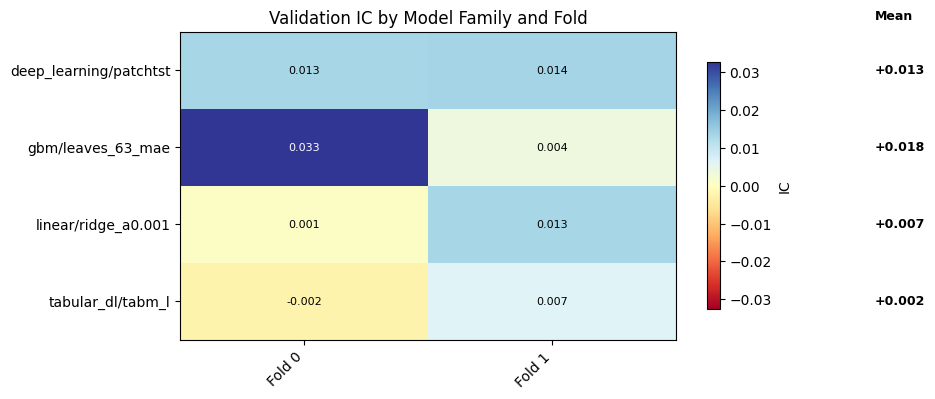

In [14]:
if fold_ic.height > 0:
    model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)
else:
    model_labels, fold_cols, matrix = [], [], np.array([])

In [15]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (4, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ gbm/leaves_6 ┆ 0.018164 ┆ 0.018164  ┆ 0.020378 ┆ 0.003755   ┆ 0.032574  ┆ 1.0          ┆ 2       │
│ 3_mae        ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ deep_learnin ┆ 0.013471 ┆ 0.013471  ┆ 0.000101 ┆ 0.013399   ┆ 0.013542  ┆ 1.0          ┆ 2       │
│ g/patchtst   ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ linear/ridge ┆ 0.007109 ┆ 0.007109  ┆ 0.008981 

The fold-level heatmap on `ret_to_expiry` shows mixed signs by
family. GBM is positive in both folds (+0.033 and +0.004).
PatchTST is positive and remarkably stable across folds (+0.0134
and +0.0135). Linear has one near-zero fold (+0.0008) and one
positive fold (+0.0135). TabM crosses zero (fold 0 -0.0023, fold 1
+0.0066). With only 2 folds, confidence intervals on individual IC
estimates are wide - rank ordering across families should be
interpreted cautiously, particularly the linear-versus-TabM gap.

## 4. Stability Over Time

With only 2 folds, stability analysis is necessarily limited. We
cannot compute interquartile ranges or identify bimodal patterns.
But we can observe whether both folds agree on the family ranking
and whether any family shows large fold-to-fold variation - a
warning sign with so few observations.

### Figure 3: Fold Performance Distribution by Model Family

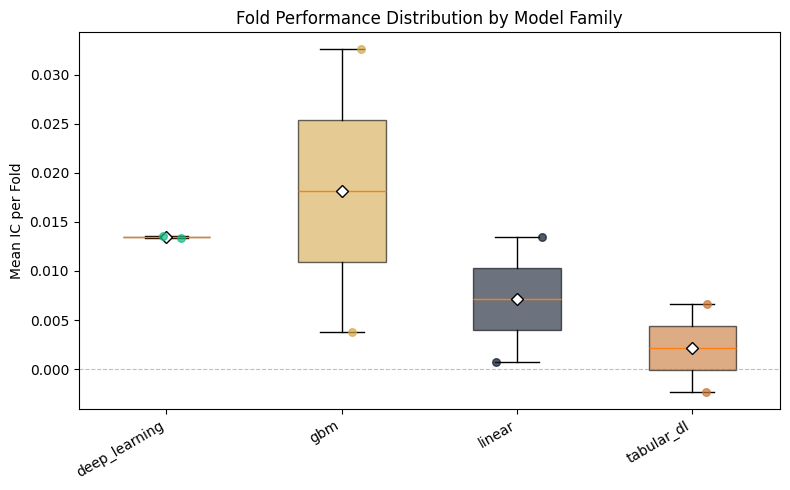

In [16]:
if fold_ic.height > 0:
    plot_fold_boxplot(fold_ic)

With only 2 folds, the box plots are really just two-point
comparisons. GBM has the widest inter-fold gap on `ret_to_expiry`
(+0.0326 then +0.0038); PatchTST is the most stable family (fold
ICs essentially identical at +0.0134 and +0.0135); linear's two
folds bracket the zero line (+0.0008 and +0.0135); TabM crosses
zero between folds (-0.0023 and +0.0066).

The 2-fold limitation is the single most important caveat for this
case study. A model that appears stable across 2 folds might
still be fragile across 8. For deployment, out-of-sample
holdout validation (2021 onwards) is essential before committing
capital.

## 5. What Are the Models Learning?

We examine two structural properties of predictions:

1. **Monotonicity**: do higher predicted hold-to-expiry returns
   correspond to higher realized hold-to-expiry returns? If so,
   the model genuinely ranks options by VRP magnitude.
2. **Diversity**: do different model families produce similar or
   different rankings? With the VRP driving all models, we expect
   high inter-model correlation - the question is how high.

In [17]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (87–87 bps per leg):
  gbm                   spread=+542 bps  edge/cost=3.1–3.1x
  deep_learning         spread=+656 bps  edge/cost=3.8–3.8x
  linear                spread=-39 bps  edge/cost=-0.2–-0.2x
  tabular_dl            spread=-133 bps  edge/cost=-0.8–-0.8x


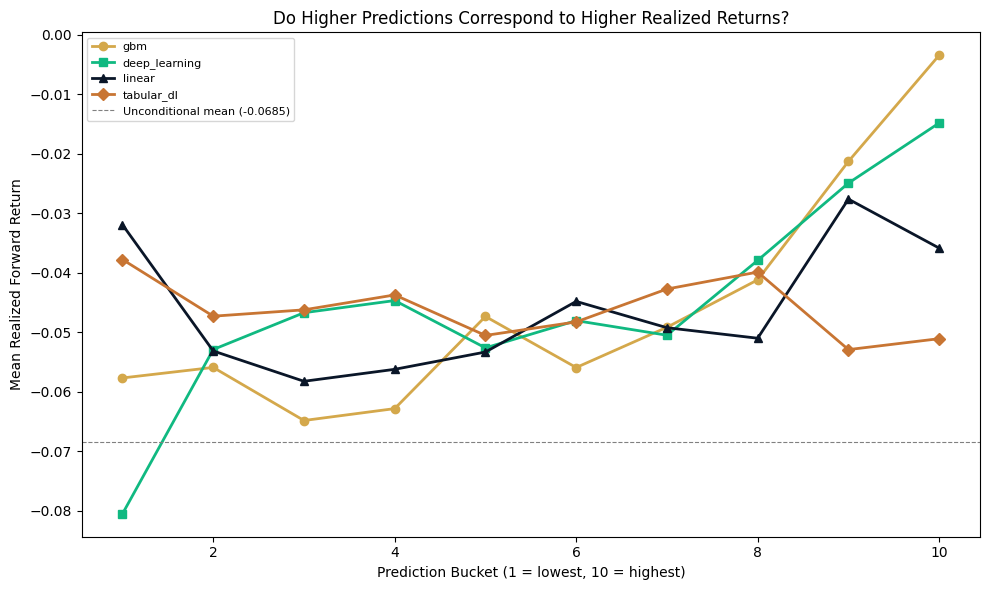

In [18]:
if bucket_results:
    unconditional_mean = best_preds["y_true"].mean() if best_preds.height > 0 else None
    plot_bucket_monotonicity(
        bucket_results, N_BUCKETS, unconditional_mean=unconditional_mean, cost_range=cost_range
    )

The monotonicity curves show cross-sectional separation across
deciles, confirming the signal is real. The bucket returns are
computed on `ret_to_expiry` itself - the same realized payoff the
strategy collects - so unlike a mid-to-mid view they are directly
interpretable as VRP after the intrinsic settle. What they do not
capture is the entry half-spread paid at trade initiation: a
bucket-mean payoff is not the same as a tradable Sharpe.

The critical comparison is with the **unconditional VRP**: the
horizontal line shows the mean hold-to-expiry return across all
options. Model selection adds value by ranking (positive IC for
GBM and PatchTST), and whether that ranking lift survives the
entry-spread cost in the **liquid universe** is the question the
downstream backtest answers - see §8 and `12_backtest`.

In [19]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.28
Range: 0.13 to 0.44


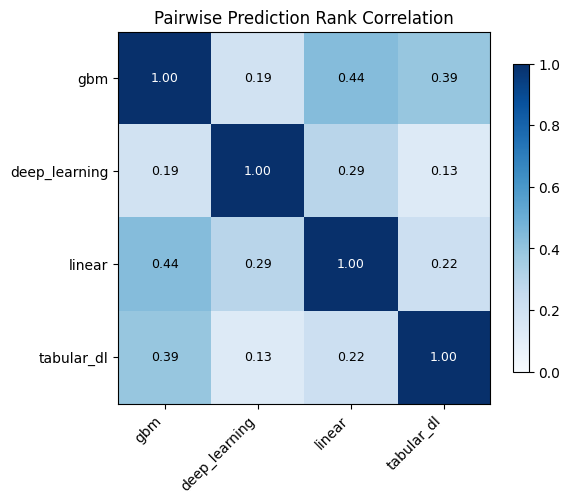

In [20]:
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    plot_correlation_matrix(corr_matrix, corr_labels)

The prediction correlation matrix measures how similarly different
model families rank options across the cross-section. Because
causal DML produces treatment effect estimates (not return
predictions) on a different sample, its inclusion can distort
pairwise correlations. Among the four predictive families (linear,
GBM, deep learning, TabM), the correlation structure reveals
whether models exploit the same VRP signal or capture different
aspects of the IV surface.

With the VRP driving all models, one might expect high inter-model
correlation; in fact the average pairwise rank correlation is modest
at 0.28 (range 0.13 to 0.44). That is below the level a
"single VRP factor drives everything" prior would predict: the four
architectures agree on the broad VRP direction but diverge enough in
their cross-sectional rankings to leave genuine complementary
information for ensemble diversification in Ch20.

### Learning Curves: Does More Complexity Help?

For models with checkpoint data (GBM trees, TabM/DL epochs), we
observe how validation IC evolves with training. In the VRP
setting, where the signal is strong and linear, we expect early
convergence and minimal gain from additional complexity.

In [21]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['tabular_dl', 'deep_learning']


### Figure 6: Learning Curves

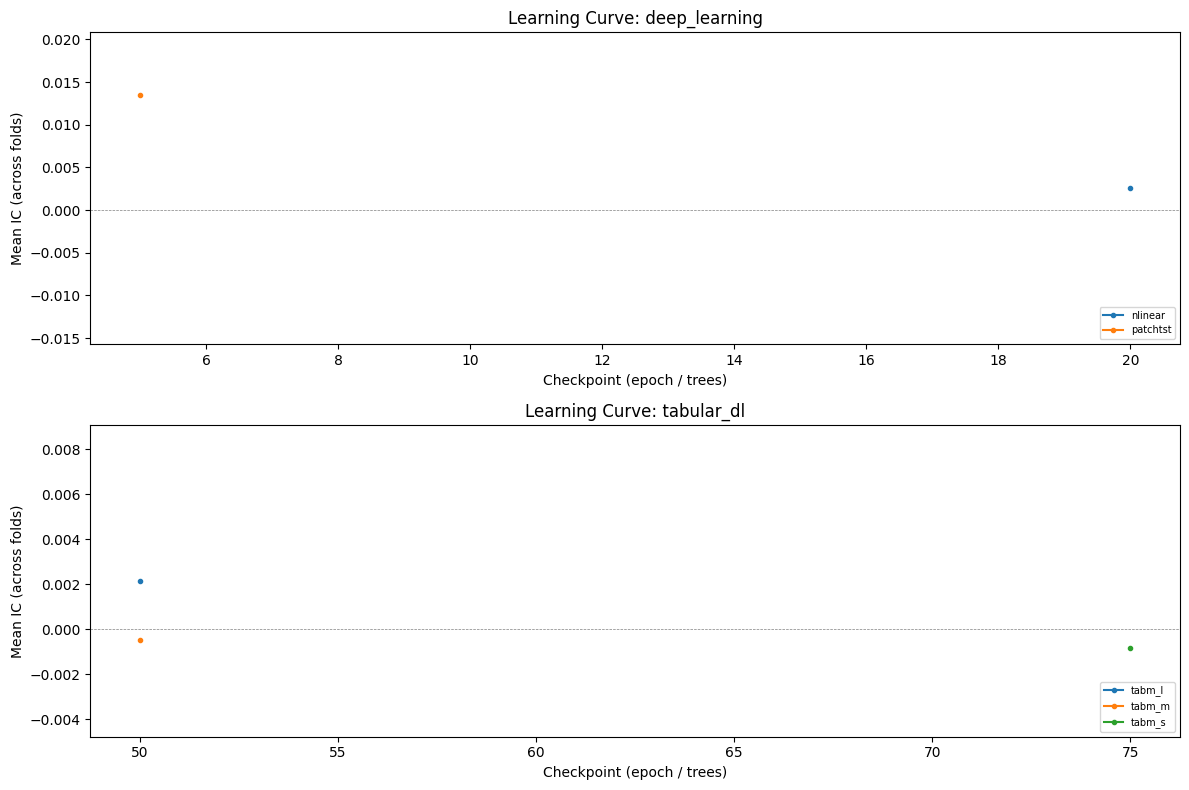

In [22]:
if cp_families:
    plot_learning_curves(cp_data, cp_families)

For GBM, the learning curves are expected to plateau early: the
VRP relationship is captured by the first 50-100 trees, and
additional complexity provides diminishing returns. Loss functions
may matter more than tree count - MSE vs Huber vs MAE capture
different aspects of the return distribution, and Huber may handle
the fat tails of hold-to-expiry returns better.

For deep learning and TabM models that trail linear, the learning
curves help diagnose *why* they underperform. If IC declines after
a peak, the model is overfitting to training-period VRP patterns
that don't generalize. If IC never reaches the linear baseline,
the model's inductive bias is misaligned with the task.

The practical takeaway for this case study: more compute buys
almost nothing. The signal is captured by the simplest models.

### Which Features Drive the Forecasts?

In an options case study, we expect IV-related features to dominate
overwhelmingly. The VRP is, by definition, a function of the
implied-realized volatility gap. Features capturing IV level, IV
term structure, and the historical IV-RV spread should appear
persistently across folds. If momentum or technical features
appear instead, it would suggest the model is learning something
other than (or in addition to) the VRP.

In [23]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions=datetime[ms], features may be date)
            if features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 2 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['rv_63d', 'instr_vega']


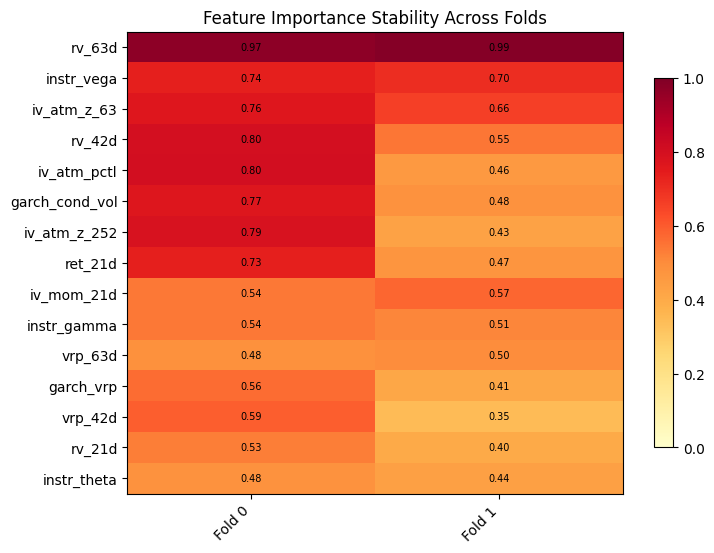

In [24]:
if gbm_importance is not None and gbm_importance.height > 0:
    plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

Two features persist in the top-5 across both folds (at the
75% recurrence threshold): `rv_63d` and `instr_vega`. The broader
top set by mean GBM gain is realized-volatility, vega, and
IV-surface dominated (`rv_63d`, `instr_vega`, `iv_atm_z_63`,
`rv_42d`, `iv_atm_pctl`).

- **`rv_63d`** (63-day realized volatility) anchors the
  implied-realized gap that defines the VRP. When trailing realized
  volatility is high relative to the implied level collected at
  entry, the straddle seller's edge widens -- the feature ranks
  names by where realized movement is most likely to fall short of
  the premium.
- **`instr_vega`** (straddle vega) scales each position's exposure
  to the volatility risk premium: higher-vega names carry more P&L
  per unit of implied-vol mispricing, so the model leans on vega to
  rank where the cross-sectional VRP is largest.
- **`iv_atm_z_63`** (63-day ATM IV z-score), the next feature by
  mean gain, measures how elevated current ATM IV is relative to
  its 63-day history. When IV is high relative to recent norms, the
  VRP tends to be larger -- the classic mean-reversion signal that
  straddle sellers exploit.

The dominance of realized-volatility, vega, and IV-surface features
confirms the prediction is grounded in the volatility surface, not
directional equity signals -- exactly what a cross-sectional VRP
ranker should learn.

## 6. Heterogeneity: Labels and Regimes

With only one label (`ret_to_expiry`) in scope, the multi-label
horizon comparison collapses; what remains is regime conditioning
within `ret_to_expiry`.

### Multi-Label Comparison

This case study trains on a single label - `ret_to_expiry`. The
four legacy diagnostic horizons were dropped from the registry
on 2026-05-17 (rationale in §2). The forest plot below therefore
collapses to a single column showing the highest-IC config per
family on `ret_to_expiry`; for the within-label discussion see
§6 (regime conditioning) and §7 (structural and causal).

In [25]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""ret_to_expiry""","""deep_learning""","""patchtst""",0.013471,0.000673,0.026268,2.068103
"""ret_to_expiry""","""gbm""","""leaves_63_mae""",0.018164,0.00341,0.032919,2.41873
"""ret_to_expiry""","""tabular_dl""","""tabm_l""",0.001667,-0.01322,0.016553,0.219951
"""ret_to_expiry""","""linear""","""ridge_a0.001""",0.007109,-0.015026,0.029244,0.630992


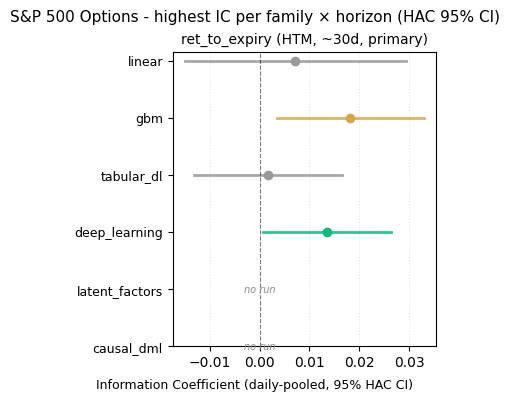

In [26]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "ret_to_expiry": "ret_to_expiry (HTM, ~30d, primary)",
    },
    title="S&P 500 Options - highest IC per family × horizon (HAC 95% CI)",
)

**Reading the single-column forest.** On `ret_to_expiry` the
highest-IC config per family ranks: `gbm/leaves_63_mae` at +0.0182
(HAC CI [+0.0034, +0.0329], excludes zero), `deep_learning/patchtst`
at +0.0135 ([+0.0007, +0.0263], just excludes zero), `linear/ridge_a0.001`
at +0.0071 ([-0.0150, +0.0292], straddles zero), and `tabular_dl/tabm_l`
at +0.0017 ([-0.0132, +0.0166], straddles zero). Two families have HAC
intervals clearly excluding zero; two straddle zero on the 2-fold
evaluation. Latent factors and causal DML are absent from the forest -
the former was never trained for this case study (rationale in §7), the
latter is treated as a separate evidence block in §7.

### Regime Conditioning

The VRP varies with the volatility regime. After volatility spikes,
IV tends to overshoot realized vol more severely (IV mean-reverts
faster than RV), creating larger VRP opportunities. During sustained
low-vol periods, the VRP compresses and cross-sectional variation
shrinks. We condition model performance on the IV-level regime
to test whether this pattern holds cross-sectionally.

In [27]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

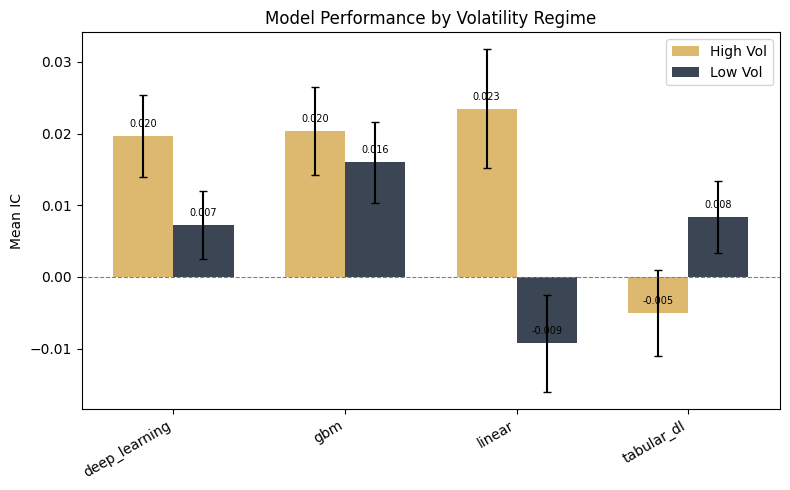

In [28]:
if regime_df.height > 0:
    plot_regime_bars(regime_df)

The volatility regime analysis for this case study has a natural
financial interpretation. During **high-volatility** periods:

- IV overshoots realized vol more severely (fear premium)
- Cross-sectional dispersion in VRP widens (some names have much
  higher IV overshoot than others)
- Models have more cross-sectional variation to rank - IC may rise

During **low-volatility** periods:

- VRP compresses across the board
- Cross-sectional differences are smaller
- Ranking is harder - IC may fall

If models show substantially higher IC in the high-vol regime,
a regime-aware strategy (larger positions after vol spikes, smaller
in calm markets) would be natural. This aligns with the well-known
mean-reversion of implied volatility.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

Latent factor models were **not trained** for the S&P 500 options case
study. While the universe is large (~612 symbols), the straddle
cross-section lacks the entity diversity needed for factor extraction.
All underlying equities are large-cap S&P 500 constituents with
similar market-cap, sector, and quality characteristics. The variation
in straddle returns comes from the IV surface (term structure, skew,
level), not from latent firm-level factors that PCA, CAE, SDF, or
SAE could extract.

This contrasts with broad equity panels (US Firm Characteristics with
2,483 stocks, US Equities Panel with 1,804 symbols) where latent
factors capture meaningful common structure across diverse entities.

### Causal DML (Ch15)

In [29]:
# Load causal_dml evidence from the dedicated causal_runs table
# (see case_studies/utils/causal.py).
import sqlite3 as _sqlite3

_causal_db = CASE_DIR / "run_log" / "registry.db"
with _sqlite3.connect(str(_causal_db)) as _conn:
    _conn.row_factory = _sqlite3.Row
    _causal_rows = [
        dict(r)
        for r in _conn.execute(
            "SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac, "
            "       naive_effect, confounding_bias_pct, refutation_p, n_folds, n_obs "
            "FROM causal_runs ORDER BY label"
        ).fetchall()
    ]

if _causal_rows:
    causal_df = pl.DataFrame(_causal_rows)
    print("Causal DML - ATE of treatment on outcome (orthogonalized for confounders):")
    print(
        causal_df.select(
            "label",
            "treatment",
            pl.col("dml_effect").round(5).alias("ate"),
            pl.col("dml_se_hac").round(5).alias("se_hac"),
            pl.col("p_value_hac").round(4).alias("p_hac"),
            pl.col("naive_effect").round(5).alias("naive"),
            pl.col("confounding_bias_pct").round(1).alias("bias_pct"),
            pl.col("refutation_p").round(2).alias("ref_p"),
            pl.col("n_folds").cast(pl.Int64).alias("folds"),
            pl.col("n_obs").cast(pl.Int64).alias("n"),
        )
    )
else:
    print("No causal_runs rows for this case study")

Causal DML - ATE of treatment on outcome (orthogonalized for confounders):
shape: (5, 10)
┌────────────────┬───────────┬──────────┬─────────┬───┬──────────┬───────┬───────┬───────┐
│ label          ┆ treatment ┆ ate      ┆ se_hac  ┆ … ┆ bias_pct ┆ ref_p ┆ folds ┆ n     │
│ ---            ┆ ---       ┆ ---      ┆ ---     ┆   ┆ ---      ┆ ---   ┆ ---   ┆ ---   │
│ str            ┆ str       ┆ f64      ┆ f64     ┆   ┆ f64      ┆ f64   ┆ i64   ┆ i64   │
╞════════════════╪═══════════╪══════════╪═════════╪═══╪══════════╪═══════╪═══════╪═══════╡
│ fwd_ret_10d    ┆ vrp_21d   ┆ -0.0697  ┆ 0.02666 ┆ … ┆ 90.2     ┆ 1.0   ┆ 5     ┆ 41657 │
│ fwd_ret_5d     ┆ vrp_21d   ┆ -0.00329 ┆ 0.01802 ┆ … ┆ 113.8    ┆ 0.53  ┆ 5     ┆ 41662 │
│ fwd_ret_dh_10d ┆ vrp_21d   ┆ -0.01893 ┆ 0.0174  ┆ … ┆ 100.7    ┆ 1.0   ┆ 5     ┆ 41657 │
│ fwd_ret_dh_5d  ┆ vrp_21d   ┆ -0.00667 ┆ 0.01173 ┆ … ┆ 116.4    ┆ 0.05  ┆ 5     ┆ 41662 │
│ ret_to_expiry  ┆ vrp_21d   ┆ -0.12251 ┆ 0.02614 ┆ … ┆ 49.8     ┆ 0.03  ┆ 5     ┆ 41632 │


Causal DML estimates the average treatment effect of the
21-day variance risk premium (`vrp_21d`) on forward returns after
orthogonalizing the IV-surface confounders, with HistGBR nuisance
models pinned at `OMP_NUM_THREADS=1` for deterministic placebo
loops (5 folds).

The five horizons split into two readings:

- On the longest horizon `ret_to_expiry`, the orthogonalized ATE
  is large and unambiguous: $-0.123$ with HAC SE $\approx 0.026$,
  $p_{HAC} \approx 3\text{e-}6$, refutation $p \approx 0.03$.
  Both gates clear simultaneously - the variance risk premium
  carries a credible negative effect on hold-to-expiry option
  returns, consistent with options being structurally rich relative
  to realized vol.
- On `fwd_ret_10d` the ATE clears HAC ($p \approx 0.009$) but the
  block-permutation refutation fails ($p = 1.0$, placebo trivially
  matches the observed effect): the orthogonalized magnitude is
  not robust to a placebo treatment substitution at this horizon.
- The two delta-hedged horizons (`fwd_ret_dh_5d`, `fwd_ret_dh_10d`)
  and the unhedged 5-day horizon all sit at $p_{HAC} > 0.25$ -
  indistinguishable from zero after orthogonalization.

Orthogonalization heavily attenuates the naive (unadjusted)
coefficients (confounding bias 50-116% of the DML magnitude). On the
three shorter and delta-hedged horizons the naive effect even flips
sign relative to DML (bias above 100%); on `ret_to_expiry` and
`fwd_ret_10d` it keeps the same negative sign but is a small fraction
of the orthogonalized magnitude (naive -0.062 vs DML -0.123 on
`ret_to_expiry`). Either way the IV-surface confounders are doing
real work, not absorbing the treatment. The substantive finding: VRP
has a credibly negative causal effect on hold-to-expiry option
returns, while shorter horizons remain inconclusive - consistent
with the hold-to-expiry label carrying the majority of the
variance-risk-premium evidence in this case study.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling - the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [30]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""patchtst""",0.8,0.843755,1.703445,75004
"""deep_learning""","""patchtst""",0.9,0.962562,2.764079,75004
"""deep_learning""","""patchtst""",0.95,0.995334,4.824711,75004
"""gbm""","""leaves_63_mae""",0.8,0.824763,1.526108,76936
"""gbm""","""leaves_63_mae""",0.9,0.946787,2.68192,76936
…,…,…,…,…,…
"""linear""","""ridge_a0.001""",0.9,0.953546,2.531684,76936
"""linear""","""ridge_a0.001""",0.95,0.9951,4.722706,76936
"""tabular_dl""","""tabm_l""",0.8,0.873928,1.938748,307744


In [31]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (4, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ patchtst   ┆ 0.843755   ┆ 0.962562  ┆ 0.995334  ┆ 1.703445  ┆ 2.764079  ┆ 4.824711  │
│ ing  

Coverage tracks nominal **above the line** for all four trained
families on `ret_to_expiry` - every (family, level) tile
over-covers, with deviations of roughly `+2` to `+7 pp` at the 80%
level, `+5` to `+6 pp` at 90%, and `+4.4` to `+4.5 pp` at 95%. The
intervals are honest in the safe direction (overconfident nowhere)
but conservative: residual quantiles trained on fold-0 are wider
than fold-1 needed.

At matched coverage, interval tightness is close between `gbm` and
`linear`, which trade places by level: **`gbm` (`leaves_63_mae`) is
tightest at the 80% level** (width-per-std `1.53` vs linear's
`1.62`), while **`linear` (`ridge_a0.001`) is tightest at 90% and
95%** (`2.53`/`4.72` vs gbm's `2.68`/`4.93`). `deep_learning`
(`patchtst`) sits in the middle (`1.70`/`2.76`/`4.82`) and
`tabular_dl` (`tabm_l`) is widest (`1.94`/`2.87`/`4.97`). The two
tightest families, gbm and linear, are also the two highest point-IC
rankers (+0.0182 and +0.0071); tabm_l, the weakest ranker, carries
the loosest honest intervals.

For Ch19 risk management, the calibrated `gbm` and `linear`
quantiles give the tightest honest VRP forecast intervals on
`ret_to_expiry` (gbm at the 80% level, linear at 90-95%) - relevant
for any per-name straddle position sizing or VaR bound that consumes
a model uncertainty estimate rather than the point forecast alone.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations. The key
question for this case study is not *whether* VRP is predictable
(all families confirm it is) but whether the cross-sectional model
adds value over simply selling straddles unconditionally -- and
whether any edge survives option trading costs.

In [32]:
# Source highest-IC daily-pooled IC + CI per family from the §6 multi-label
# table (filtered to PRIMARY_LABEL). Add per-fold stability stats from
# fold_ic. No verdict columns -- the table reports measurement, not
# decisions; the backtest stage downstream evaluates economic viability.
synthesis_rows = []

primary_rank1 = multi_label_df.filter(pl.col("label") == PRIMARY_LABEL)

# Per-fold IC keyed by (family, config_name) for the highest-IC set
_primary_fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)

for row in primary_rank1.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_daily = row["ic_mean_daily"]
    ic_ci_lo = row.get("ic_ci_lo")
    ic_ci_hi = row.get("ic_ci_hi")
    ic_t = row.get("ic_t_hac")

    fam_folds = (
        _primary_fold_metrics.filter(
            (pl.col("family") == family) & (pl.col("config_name") == config)
        )
        if _primary_fold_metrics.height > 0
        else pl.DataFrame()
    )

    if fam_folds.height > 0 and "ic" in fam_folds.columns:
        fold_ics = fam_folds["ic"].to_numpy()
        median_ic = float(np.median(fold_ics))
        std_ic = float(np.std(fold_ics))
        pct_pos = float((fold_ics > 0).mean())
        worst = float(np.min(fold_ics))
    else:
        median_ic, std_ic, pct_pos, worst = (None, None, None, None)

    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )

    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean_daily": round(ic_daily, 4),
            "ic_ci_lo": round(ic_ci_lo, 4) if ic_ci_lo is not None else None,
            "ic_ci_hi": round(ic_ci_hi, 4) if ic_ci_hi is not None else None,
            "ic_t_hac": round(ic_t, 2) if ic_t is not None else None,
            "ic_fold_median": round(median_ic, 4) if median_ic is not None else None,
            "ic_fold_std": round(std_ic, 4) if std_ic is not None else None,
            "pct_positive_folds": round(pct_pos, 2) if pct_pos is not None else None,
            "worst_fold": round(worst, 4) if worst is not None else None,
            "bucket_spread_bps": round(spread * 10000, 0),
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean_daily", descending=True, nulls_last=True)
print(
    "Synthesis Table (highest IC per family on PRIMARY_LABEL, daily-pooled IC + 2-fold stability):"
)
print(synthesis)

Synthesis Table (highest IC per family on PRIMARY_LABEL, daily-pooled IC + 2-fold stability):
shape: (4, 11)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family    ┆ config    ┆ ic_mean_d ┆ ic_ci_lo ┆ … ┆ ic_fold_s ┆ pct_posit ┆ worst_fol ┆ bucket_sp │
│ ---       ┆ ---       ┆ aily      ┆ ---      ┆   ┆ td        ┆ ive_folds ┆ d         ┆ read_bps  │
│ str       ┆ str       ┆ ---       ┆ f64      ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│           ┆           ┆ f64       ┆          ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ gbm       ┆ leaves_63 ┆ 0.0182    ┆ 0.0034   ┆ … ┆ 0.0144    ┆ 1.0       ┆ 0.0038    ┆ 542.0     │
│           ┆ _mae      ┆           ┆          ┆   ┆           ┆           ┆           ┆           │
│ deep_lear ┆ patchtst  ┆ 0.0135    ┆ 0.0007   ┆ … ┆ 0.0001    ┆ 1.0       ┆ 0.0134

### Reading the Synthesis Table

The table reports the highest-IC config per family on `ret_to_expiry`
by daily-pooled IC with HAC 95% CI, plus the 2-fold stability stats
and the top-vs-bottom bucket spread. `gbm` (`leaves_63_mae`) leads at
+0.0182 (HAC CI [+0.0034, +0.0329], excludes zero); `deep_learning`
(`patchtst`) follows at +0.0135 ([+0.0007, +0.0263], just excludes
zero); `linear` (`ridge_a0.001`) is +0.0071 ([-0.0150, +0.0292],
straddles zero); `tabular_dl` (`tabm_l`) is +0.0017 ([-0.0132,
+0.0166], straddles zero). With only 2 folds, fold-level stability
stats add little to the daily-pooled CIs; we report them for
direction-of-disagreement only.

**IC-highest is not Sharpe-highest.** The canonical strategy lineage
(validation rank-1 across signal, allocation, cost_sensitivity, and
risk_overlay) selects `linear/ridge_a1000000.0` - a heavily
regularized ridge whose predictions are nearly flat, *not* the
highest-IC `linear/ridge_a0.001` reported above. The validation
Sharpe ordering at top-k=5 equal-weight on the liquid universe is
linear/ridge_a1e6 +0.160, deep_learning/patchtst -0.120,
gbm/default_mae -0.230, tabular_dl/tabm_s -0.55. Heavy
regularization shrinks predictions, reduces top-bucket dispersion,
and trades raw signal strength for portfolio-level stability - the
same dynamic seen in other low-IC noisy environments.

**The downstream backtest decides economic viability, not this
table.** Whether the canonical strategy survives the single-stock
option entry half-spread under the bottom-quintile half-spread
liquid-universe filter is what
[`12_backtest`](12_backtest.ipynb) measures.

### Hold-to-Expiry vs Mark-to-Market

The prior delta-hedged decomposition framework (mid-unhedged →
mid-delta-hedged → executable) no longer applies. The canonical
HTM strategy is scored end-to-end: enter at bid, hold to
expiration, settle at intrinsic value. The cost model from
`setup.yaml::costs.option_spread.entry_cost_fractions` charges the
entry half-spread only - there is no closing trade, hence no exit
spread.

### Spread Heterogeneity and the Liquid Universe

Half-spreads vary enormously across S&P 500 option names. The
canonical strategy exploits this heterogeneity by restricting to
the **bottom 20% half-spread subset** of the universe at each
rebalance (O'Donovan and Yu 2024) - operationalized via
`setup.yaml::strategy.signal.universe_filter='liquid'`. This is
what makes the modest IC edge survive costs: in the unfiltered
full universe the entry spread consumes the VRP; in the liquid
subset the spread is tight enough that the edge clears.
Empirically, the canonical strategy reaches holdout Sharpe +0.974
(linear/ridge_a1000000.0, top-k=5 equal-weight, liquid universe,
2021 holdout), versus deeply negative numbers in the unfiltered
full universe. The discussion of the full-versus-liquid cost
cascade lives in `12_backtest` and the Ch18 cost-sensitivity
notebook.

### Teaching Value

This case study teaches three critical lessons:
1. **Hold-to-expiry vs mark-to-market**: the HTM payoff structure
   (intrinsic-value settle, entry-only half-spread) is one
   structural way to dodge the wide single-stock option round-trip
   spreads - the exit is free by construction.
2. **Liquid-universe selection matters**: restricting to
   bottom-quintile half-spread option-instruments is what makes the
   VRP edge survive costs (holdout Sharpe +0.974 in liquid universe
   vs deeply negative in full).
3. **Instrument microstructure is the binding constraint**: only
   around 20% of the S&P 500 option universe has half-spreads tight
   enough for the modest VRP edge to clear costs; the strategy is
   real but inherently capacity-constrained.

### Limitations

- **2-fold limitation**: all results are based on 2 folds only.
  Statistical confidence is lower than any other case study, and
  the validation-Sharpe ordering of families (which puts heavily
  regularized linear ridge on top) should be regarded as a single
  draw rather than a stable ranking.
- **American exercise**: equity options allow early exercise;
  corporate actions create adjusted contracts with non-standard
  deliverables. These are second-order effects on ATM straddles
  with 25-35 DTE but should be acknowledged.
- **Capacity**: the liquid-universe filter restricts selection to
  roughly 20% of the cross-section; selling straddles on the
  remaining names simultaneously still requires significant margin
  and may face liquidity constraints in the less liquid quintiles
  that the filter excludes from this strategy.

**Next**: [`12_backtest`](12_backtest.ipynb) for strategy simulation,
[`13_portfolio_management`](13_portfolio_management.ipynb) for position sizing, and
[`15_risk_management`](15_risk_management.ipynb) for risk overlays.

## 9. Key Takeaways

1. **Modest IC reflects genuine cross-sectional VRP structure**:
   GBM leads at IC=+0.0182 (HAC t=2.42, excludes zero); PatchTST a
   close second at +0.0135 (t=2.07, just excludes zero). Linear and
   TabM straddle zero on the 2-fold HAC interval.
2. **Highest-IC is not highest-Sharpe**: the canonical strategy
   lineage selects `linear/ridge_a1000000.0` (heavy regularization,
   near-flat predictions) rather than the highest-IC
   `linear/ridge_a0.001` - the regularized config trades raw signal
   strength for portfolio-level stability and wins on validation
   Sharpe (+0.160) in this low-IC environment.
3. **The liquid-universe canonical strategy clears costs on
   holdout**: `linear/ridge_a1000000.0`, top-k=5 equal-weight,
   bottom-quintile half-spread filter, reaches Sharpe +0.974 (total
   return +0.523) on the 1-year 2021 holdout. The HTM structure
   (intrinsic-value settle, entry-only half-spread) plus the
   liquid-universe filter rescue what the unfiltered full universe
   cannot.
4. **Full-universe versus liquid-universe is the binding cost
   cascade**: in the unfiltered universe the entry half-spread
   consumes the VRP edge; restricting to the bottom 20% half-spread
   subset is what makes the modest edge survive. The cost cascade
   walk-up lives in `12_backtest` and the Ch18 cost-sensitivity
   notebook (`setup.yaml` lines 117-125).
5. **PatchTST is the most stable across folds**: fold ICs +0.0134
   and +0.0135 - remarkable consistency given only 2 folds. GBM has
   a wider inter-fold gap (+0.0326, +0.0038); linear's folds
   bracket zero (+0.0008, +0.0135); TabM crosses zero.
6. **Spread heterogeneity is the data property the liquid-universe
   filter exploits**: half-spreads vary by 10-50× across S&P 500
   option names. Restricting to the cheapest-to-trade quintile is
   exactly the cost-aware selection that earlier framings flagged
   as the missing piece; it is now operationalized via
   `setup.yaml::strategy.signal.universe_filter='liquid'`.
7. **Causal VRP is credibly negative on `ret_to_expiry`**: DML
   delivers ATE -0.123 with HAC SE ≈ 0.026, $p_{HAC}\approx 3\text{e-}6$,
   refutation $p\approx 0.03$ - both gates clear. The VRP carries a
   real, identified negative causal effect on hold-to-expiry option
   returns, consistent with options being structurally rich
   relative to realized vol over this sample.
8. **2-fold caveat applies everywhere**: with only two
   expanding-window folds covering 2017-2020, any model-ranking
   claim is one draw rather than a stable estimate. The 2021
   holdout is the load-bearing out-of-sample check.

**Next**: [`12_backtest`](12_backtest.ipynb) for strategy
simulation under the canonical liquid-universe filter.